**Oasis Infobyte Internship**

Task 3
Data Cleaning and Quality Improvement – Titanic Dataset

Objective:
To identify and correct data quality issues such as missing values, duplicates, inconsistent formatting, outliers, and incorrect data types, and transform the Titanic dataset into a clean, analysis-ready dataset.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()


Saving tested.csv to tested.csv


In [6]:
df = pd.read_csv("tested.csv")

In [8]:
print("Database Shape:" , df.shape)

print("Missing values:")
print(df.isnull().sum())

print('/nDuplicate Rows:')
print(df.duplicated().sum())

print("n\nData Types:")
print(df.dtypes)

print('n\nBasic Statistics:')
display(df.describe(include="all"))

Database Shape: (418, 12)
Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
/nDuplicate Rows:
0
n
Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
n
Basic Statistics:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Peter, Master. Michael J",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [9]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Fare with median
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Cabin has many missing values, so fill with "Unknown"
df['Cabin'] = df['Cabin'].fillna('Unknown')

# Check missing values after treatment
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
# Check unique values in categorical columns
print("Sex:", df['Sex'].unique())
print("Embarked:", df['Embarked'].unique())

# Standardize text formatting
df['Sex'] = df['Sex'].str.strip().str.lower()
df['Embarked'] = df['Embarked'].str.strip().str.upper()

print("\nAfter cleaning:")
print("Sex:", df['Sex'].unique())
print("Embarked:", df['Embarked'].unique())

Sex: ['male' 'female']
Embarked: ['Q' 'S' 'C']

After cleaning:
Sex: ['male' 'female']
Embarked: ['Q' 'S' 'C']


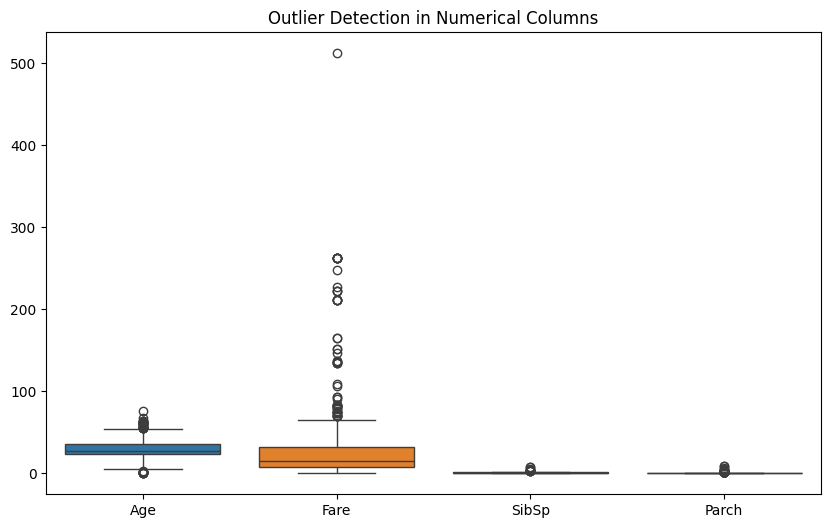

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Age', 'Fare', 'SibSp', 'Parch']])
plt.title("Outlier Detection in Numerical Columns")
plt.show()

In [14]:
# IQR method to identify outliers

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

Age: 36 outliers
Fare: 55 outliers
SibSp: 11 outliers
Parch: 94 outliers


### Outlier Treatment

The IQR method identified outliers in Age, Fare, SibSp, and Parch.

The detected outliers were retained because they may represent genuine passenger characteristics. For example, higher fares can correspond to premium-class tickets, while higher SibSp and Parch values can represent passengers travelling with larger families.

No values were capped or removed because there was no clear evidence that these observations were data-entry errors.

In [15]:
# Correct data types
df['PassengerId'] = df['PassengerId'].astype(str)
df['Survived'] = df['Survived'].astype(int)
df['Pclass'] = df['Pclass'].astype(int)
df['Age'] = df['Age'].astype(float)
df['Fare'] = df['Fare'].astype(float)

print(df.dtypes)

PassengerId     object
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [16]:
print("BEFORE CLEANING")
print("Rows:", 418)
print("Columns:", 12)
print("Missing values:", 414)
print("Duplicate rows:", 0)

print("\nAFTER CLEANING")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

BEFORE CLEANING
Rows: 418
Columns: 12
Missing values: 414
Duplicate rows: 0

AFTER CLEANING
Rows: 418
Columns: 12
Missing values: 0
Duplicate rows: 0


In [17]:
# Save cleaned dataset as a new CSV file
df.to_csv("Titanic_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully as Titanic_Cleaned.csv")

Cleaned dataset saved successfully as Titanic_Cleaned.csv


### Conclusion

The Titanic dataset was cleaned and prepared for further analysis by handling missing values, checking duplicate records, standardizing categorical values, reviewing outliers, and correcting data types. Missing Age, Fare, and Cabin values were appropriately treated, while potential outliers were retained because they could represent genuine passenger characteristics. The cleaned dataset was saved as a new CSV file and is now ready for analysis.